In [2]:
import json
import pandas as pd

with open("master_meetings.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

# If data is a dict
if isinstance(data, dict):

    # Common case:
    if "meetings" in data:
        df = pd.DataFrame(data["meetings"])

    else:
        df = pd.DataFrame.from_dict(
            data,
            orient="index"
        )

else:
    df = pd.DataFrame(data)

print(df.head())
print(df.columns.tolist())

print(df["overall_sentiment"].value_counts(dropna=False))
print("\n")
print(df["sentiment_score"].describe())

<class 'dict'>
                 meeting_id  \
0  01KQ03B0303900521BB089CA   
1  01KQ0C1280EDA4E70AAD7C35   
2  01KQ0CAE7F064EC93F0540CA   
3  01KQ0DFE299AC7A74E8022CA   
4  01KQ0F8AFF3DA34FD4580008   

                                               title  \
0            Detect Outage - Remediation Plan Review   
1  Support Case #9279 - Summit Trust Billing Inquiry   
2                         Weekly Engineering Standup   
3   Aegis / Redwood Clinical - ISO 27001 Preparation   
4              Aegis / Cobalt Software - Q2 Planning   

               organizer_email                   host_email  \
0  megan.lawson@aegiscloud.com  megan.lawson@aegiscloud.com   
1    sarah.chen@aegiscloud.com    sarah.chen@aegiscloud.com   
2     chris.lee@aegiscloud.com     chris.lee@aegiscloud.com   
3  kevin.obrien@aegiscloud.com  kevin.obrien@aegiscloud.com   
4     lisa.park@aegiscloud.com     lisa.park@aegiscloud.com   

                 start_time                  end_time  duration_minutes  \
0  2026

Meetings: 100

===== SENTIMENT SUMMARY =====

          call_type  meeting_count  avg_sentiment  min_sentiment  \
0  customer_support             33       2.412121            1.4   
1          external             56       3.917857            2.1   
2          internal             11       3.872727            3.4   

   max_sentiment  
0            3.9  
1            4.9  
2            4.8  

===== DISTRIBUTION (%) =====

overall_sentiment  mixed-negative  mixed-positive  negative  positive  \
call_type                                                               
customer_support            69.70           12.12     12.12      0.00   
external                    17.86           39.29      0.00      7.14   
internal                     0.00           63.64      0.00     27.27   

overall_sentiment  very-negative  very-positive  
call_type                                        
customer_support            6.06           0.00  
external                    0.00          35.71  
internal

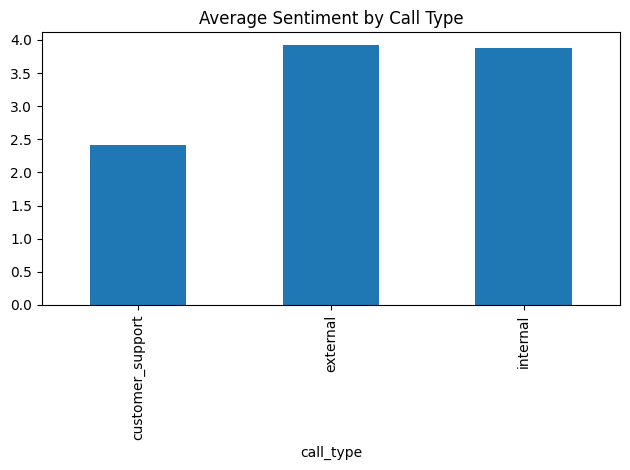

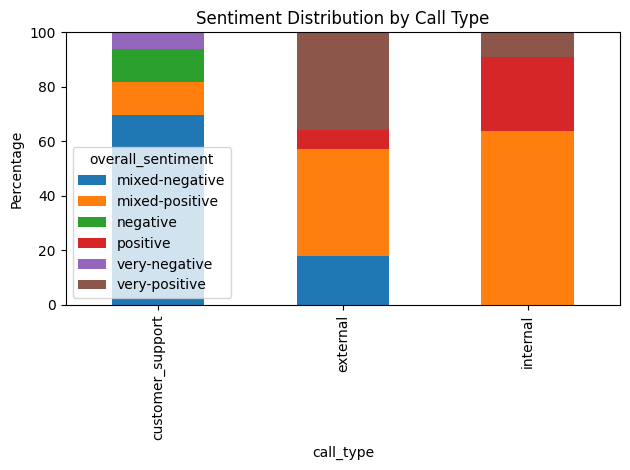

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# Load master meetings
# ------------------------

with open("master_meetings.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Your file is a dict
df = pd.DataFrame(data["meetings"]) if "meetings" in data else pd.DataFrame(data)

# ------------------------
# Load themes
# ------------------------

themes = pd.read_csv("themes_by_meeting.csv")

# ------------------------
# Theme → Call Type
# ------------------------

theme_map = {
    "customer_support_escalation": "customer_support",

    "compliance_audit": "external",
    "renewal_expansion": "external",
    "onboarding_implementation": "external",
    "product_feedback_feature_gap": "external",
    "competitive_review": "external",

    "internal_planning_roadmap": "internal"
}

themes["call_type"] = themes["assigned_theme"].map(theme_map)

# ------------------------
# Merge
# ------------------------

merged = df.merge(
    themes[["meeting_id", "call_type"]],
    on="meeting_id",
    how="inner"
)

print("Meetings:", len(merged))

# ------------------------
# Sentiment Summary
# ------------------------

summary = (
    merged.groupby("call_type")
    .agg(
        meeting_count=("meeting_id", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        min_sentiment=("sentiment_score", "min"),
        max_sentiment=("sentiment_score", "max")
    )
    .reset_index()
)

print("\n===== SENTIMENT SUMMARY =====\n")
print(summary)

# ------------------------
# Sentiment Distribution
# ------------------------

distribution = (
    pd.crosstab(
        merged["call_type"],
        merged["overall_sentiment"],
        normalize="index"
    ) * 100
)

print("\n===== DISTRIBUTION (%) =====\n")
print(distribution.round(2))

# ------------------------
# Export
# ------------------------

summary.to_csv(
    "sentiment_summary.csv",
    index=False
)

distribution.to_csv(
    "sentiment_distribution.csv"
)

# ------------------------
# Plot 1
# ------------------------

summary.plot(
    x="call_type",
    y="avg_sentiment",
    kind="bar",
    legend=False
)

plt.title(
    "Average Sentiment by Call Type"
)

plt.tight_layout()

plt.savefig(
    "avg_sentiment_by_call_type.png"
)

plt.show()

# ------------------------
# Plot 2
# ------------------------

distribution.plot(
    kind="bar",
    stacked=True
)

plt.title(
    "Sentiment Distribution by Call Type"
)

plt.ylabel("Percentage")

plt.tight_layout()

plt.savefig(
    "sentiment_distribution_by_type.png"
)

plt.show()

In [7]:
print(summary)
print(distribution)

          call_type  meeting_count  avg_sentiment  min_sentiment  \
0  customer_support             33       2.412121            1.4   
1          external             56       3.917857            2.1   
2          internal             11       3.872727            3.4   

   max_sentiment  
0            3.9  
1            4.9  
2            4.8  
overall_sentiment  mixed-negative  mixed-positive   negative   positive  \
call_type                                                                 
customer_support        69.696970       12.121212  12.121212   0.000000   
external                17.857143       39.285714   0.000000   7.142857   
internal                 0.000000       63.636364   0.000000  27.272727   

overall_sentiment  very-negative  very-positive  
call_type                                        
customer_support        6.060606       0.000000  
external                0.000000      35.714286  
internal                0.000000       9.090909  
